# **Exploratory Data Analysis (EDA)**

## Objectives

The objectives of this notebook are to:

- Explore the cleaned Premier League player dataset.
- Understand the distribution of player statistics.
- Investigate relationships between features.
- Explore the target variable.
- Identify features that may contribute to accurately classifying Premier League players as high goal scorers.
- Identify potential data leakage and highly correlated features.
- Summarise the findings to inform the machine learning stage.


## Inputs

- `data/processed/all_players_cleaned.csv`

## Outputs

- Summary statistics
- Visualisations of feature distributions
- Target variable analysis
- Correlation analysis
- Feature selection recommendations
- Evidence to support model development

## Additional Comments

The purpose of this notebook is exploratory rather than corrective. No data cleaning is performed unless a previously unidentified issue is discovered. The analysis focuses on understanding the characteristics of the cleaned dataset and identifying features suitable for predictive modelling.

---

### Change working directory

In [109]:
import os
current_dir = os.getcwd()
current_dir

'C:\\code\\premier-league-predictor\\premier-league-predictor'

In [110]:
os.chdir(r"C:\code\premier-league-predictor\premier-league-predictor")
print("You set a new current directory")

You set a new current directory


In [111]:
current_dir = os.getcwd()
current_dir

'C:\\code\\premier-league-predictor\\premier-league-predictor'

### Import packages

All data loading and inspection in this notebook uses `pandas`. No additional libraries are needed at this stage.

In [112]:

import pandas as pd

## Load processed dataset

The merged dataset created during the data collection stage is loaded from the `data/processed` directory. This dataset will be assessed for data quality issues before exploratory data analysis.

In [113]:
data_path = "data/processed"
file_path = os.path.join(data_path, "all_players_cleaned.csv")

df = pd.read_csv(file_path)

## Inspect dataset

The dataset is inspected to confirm it has loaded correctly and to obtain an initial understanding of its size, structure and data types before cleaning begins.

In [114]:
df.shape


(8196, 54)

In [115]:
df.head()

,Name,Position,Appearances,Clean sheets,Goals conceded,Tackles,Tackle success %,Last man tackles,Blocked shots,Interceptions,...,Big chances missed,Saves,Penalties saved,Punches,High Claims,Catches,Sweeper clearances,Throw outs,Goal Kicks,Season
0,Rolando Aarons,Midfielder,10,NaN,NaN,13.0,77.0,NaN,0.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
1,Almen Abdi,Midfielder,32,NaN,NaN,83.0,78.0,NaN,10.0,32.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
2,Abdul Rahman Baba,Defender,15,2.0,13.0,47.0,83.0,0.0,1.0,23.0,...,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
3,Mehdi Abeid,Midfielder,0,NaN,NaN,0.0,0.0,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
4,Tammy Abraham,Forward,2,NaN,NaN,0.0,NaN,NaN,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8196 entries, 0 to 8195
Data columns (total 54 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Name                    8196 non-null   object 
 1   Position                8196 non-null   object 
 2   Appearances             8196 non-null   int64  
 3   Clean sheets            3577 non-null   float64
 4   Goals conceded          3577 non-null   float64
 5   Tackles                 7235 non-null   float64
 6   Tackle success %        5523 non-null   float64
 7   Last man tackles        2616 non-null   float64
 8   Blocked shots           7235 non-null   float64
 9   Interceptions           7235 non-null   float64
 10  Clearances              7235 non-null   float64
 11  Headed Clearance        7235 non-null   float64
 12  Clearances off line     2616 non-null   float64
 13  Recoveries              5523 non-null   float64
 14  Duels won               5523 non-null   

### Generate summary statistics

In [146]:
df.describe(include='all')

,Name,Position,Appearances,Clean sheets,Goals conceded,Tackles,Tackle success %,Last man tackles,Blocked shots,Interceptions,...,Saves,Penalties saved,Punches,High Claims,Catches,Sweeper clearances,Throw outs,Goal Kicks,Season,HighScorer
count,8196,8196,8196.000000,3577.000000,3577.000000,7235.000000,5523.000000,2616.000000,7235.000000,7235.000000,...,8196.000000,8196.000000,8196.000000,8196.000000,8196.000000,8196.000000,8196.000000,8196.000000,8196,8196
unique,3718,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,2
top,Alex Oxlade-Chamberlain,Midfielder,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-23,False
freq,6,2877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1086,7984
mean,NaN,NaN,10.952050,2.259435,12.599105,15.046026,33.107550,0.149465,3.113476,9.929648,...,2.366398,0.015617,0.337482,0.616642,0.180332,0.405076,3.450220,5.917033,NaN,NaN
std,NaN,NaN,13.269553,3.752823,17.605936,22.532904,33.615624,0.470368,5.736301,16.606511,...,14.510675,0.153861,2.301140,4.133015,1.282894,2.786947,21.588437,36.064425,NaN,NaN
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,NaN,NaN,2.000000,0.000000,0.000000,2.000000,39.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,NaN,NaN,23.000000,4.000000,24.000000,24.000000,63.000000,0.000000,4.000000,14.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN


In [147]:
df["Position"].value_counts()

Position
Midfielder    2877
Defender      2634
Forward       1724
Goalkeeper     961
Name: count, dtype: int64

### Position distribution

The dataset contains player-season observations from four playing positions. Midfielders represent the largest proportion of the dataset, followed closely by defenders, then forwards and goalkeepers.

This distribution is expected because football teams can only field one goalkeeper, and many formations also include a greater number of defenders and midfielders than forwards. As a result, the dataset naturally contains more midfielder observations across the nine Premier League seasons.

In [119]:
df["Position"].value_counts(normalize=True) * 100

Position
Midfielder    35.102489
Defender      32.137628
Forward       21.034651
Goalkeeper    11.725232
Name: proportion, dtype: float64

In [120]:
df["Season"].value_counts()

Season
2022-23    1086
2023-24    1016
2021-22     989
2019-20     974
2018-19     882
2020-21     862
2016-17     837
2017-18     793
2015-16     757
Name: count, dtype: int64

## Explore the target variable

Before creating the target variable for the classification model, the distribution of goals is explored. This helps determine whether a threshold of more than 10 goals is an appropriate definition of a high goal scorer and ensures the classification target is supported by the underlying data.

In [121]:
df["Goals"].value_counts().sort_index()

Goals
0     5925
1      804
2      430
3      240
4      176
5      134
6      102
7       74
8       59
9       40
10      52
11      34
12      22
13      20
14      10
15      14
16      11
17       9
18       7
19       5
20       4
21       3
22       7
23       4
24       3
25       2
27       1
30       2
32       1
36       1
Name: count, dtype: int64

In [122]:
(df["Goals"] > 10).sum()

np.int64(160)

In [123]:
(df["Goals"] > 10).mean() * 100

np.float64(1.9521717911176184)

In [124]:
((df["Goals"] >=7) & (df["Goals"] <=9)).sum()

np.int64(173)

In [125]:
df.groupby("Position")["Goals"].mean()

Position
Defender      0.418375
Forward       2.732019
Goalkeeper    0.001041
Midfielder    1.004866
Name: Goals, dtype: float64

In [126]:
df[df["Goals"] >= 10]

,Name,Position,Appearances,Clean sheets,Goals conceded,Tackles,Tackle success %,Last man tackles,Blocked shots,Interceptions,...,Big chances missed,Saves,Penalties saved,Punches,High Claims,Catches,Sweeper clearances,Throw outs,Goal Kicks,Season
11,Sergio Agüero,Forward,30,NaN,NaN,15.0,NaN,NaN,26.0,6.0,...,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
22,Dele Alli,Midfielder,33,NaN,NaN,71.0,75.0,NaN,27.0,61.0,...,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
39,Marko Arnautovic,Forward,34,NaN,NaN,53.0,NaN,NaN,12.0,28.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
179,Troy Deeney,Forward,38,NaN,NaN,49.0,NaN,NaN,34.0,17.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
180,Jermain Defoe,Forward,33,NaN,NaN,17.0,NaN,NaN,26.0,2.0,...,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2015-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8050,Son Heung-Min,Forward,35,NaN,NaN,21.0,NaN,NaN,22.0,8.0,...,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-24
8104,Leandro Trossard,Forward,34,NaN,NaN,27.0,NaN,NaN,19.0,8.0,...,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-24
8145,Ollie Watkins,Forward,37,NaN,NaN,12.0,NaN,NaN,21.0,4.0,...,22.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-24
8169,Yoane Wissa,Midfielder,34,NaN,NaN,28.0,57.0,NaN,15.0,9.0,...,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-24


In [151]:
df[df["Goals"] >= 10].groupby("Position").size()

Position
Forward       174
Midfielder     38
dtype: int64

Text(0, 0.5, 'Number of Player-Seasons')

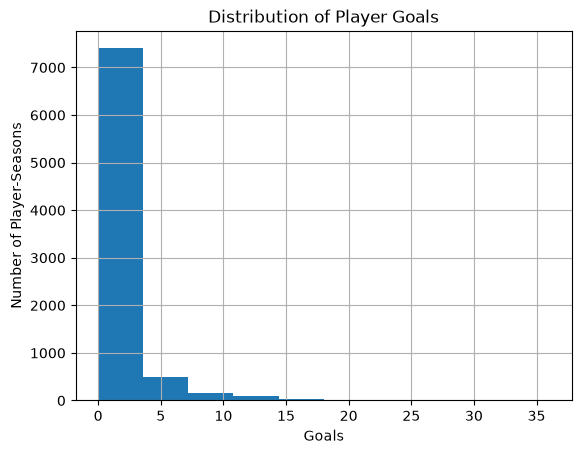

In [150]:
ax = df["Goals"].hist(bins=10)

ax.set_title("Distribution of Player Goals")
ax.set_xlabel("Goals")
ax.set_ylabel("Number of Player-Seasons")

In [129]:
(df["Goals"] >= 10).mean() * 100

np.float64(2.5866276232308443)

### Target Variable Observations

The goal distribution is heavily weighted towards lower goal totals, with the majority of player-season observations recording few or no goals.

Using a threshold of **10 or more goals**, 212 player-season observations would be classified as high goal scorers. This represents approximately **2.6% of the dataset**, indicating a significant class imbalance between high and non-high goal scorers.

When the high-scoring observations were grouped by position, **174 were forwards and 38 were midfielders**. No defenders or goalkeepers scored 10 or more goals during the seasons included in the dataset. This demonstrates that playing position is likely to have an important relationship with the target variable.

The class imbalance will need to be considered during model development, as accuracy alone may provide a misleading measure of model performance.

## Explore Potential Predictor Features

The next stage of the analysis investigates player statistics that may help distinguish high goal scorers from non-high goal scorers. Features will be explored based on their relevance to attacking performance and their potential relationship with the target variable.

In [130]:
df.columns.tolist()

['Name',
 'Position',
 'Appearances',
 'Clean sheets',
 'Goals conceded',
 'Tackles',
 'Tackle success %',
 'Last man tackles',
 'Blocked shots',
 'Interceptions',
 'Clearances',
 'Headed Clearance',
 'Clearances off line',
 'Recoveries',
 'Duels won',
 'Duels lost',
 'Successful 50/50s',
 'Aerial battles won',
 'Aerial battles lost',
 'Own goals',
 'Errors leading to goal',
 'Assists',
 'Passes',
 'Passes per match',
 'Big chances created',
 'Crosses',
 'Cross accuracy %',
 'Through balls',
 'Accurate long balls',
 'Yellow cards',
 'Red cards',
 'Fouls',
 'Offsides',
 'Goals',
 'Headed goals',
 'Goals with right foot',
 'Goals with left foot',
 'Hit woodwork',
 'Goals per match',
 'Penalties scored',
 'Freekicks scored',
 'Shots',
 'Shots on target',
 'Shooting accuracy %',
 'Big chances missed',
 'Saves',
 'Penalties saved',
 'Punches',
 'High Claims',
 'Catches',
 'Sweeper clearances',
 'Throw outs',
 'Goal Kicks',
 'Season']

In [131]:
df["Goals"] >= 10

0       False
1       False
2       False
3       False
4       False
        ...  
8191    False
8192    False
8193    False
8194    False
8195    False
Name: Goals, Length: 8196, dtype: bool

In [148]:
df["HighScorer"] = df["Goals"] >= 10
df["HighScorer"].value_counts()


HighScorer
False    7984
True      212
Name: count, dtype: int64

In [133]:
df.groupby("HighScorer")["Shots"].mean()

HighScorer
False    11.408214
True     80.231132
Name: Shots, dtype: float64

In [149]:
df.groupby("HighScorer")["Shots on target"].mean()

HighScorer
False     3.812798
True     34.353774
Name: Shots on target, dtype: float64

In [135]:
df.groupby("HighScorer")["Shooting accuracy %"].mean()

HighScorer
False    15.617881
True     43.457547
Name: Shooting accuracy %, dtype: float64

In [136]:
df.groupby("HighScorer")["Appearances"].mean()

HighScorer
False    10.365982
True     33.023585
Name: Appearances, dtype: float64

In [137]:
df.groupby("HighScorer")["Shots"].agg(["mean", "median"])

,mean,median
HighScorer,,
False,11.408214,0.0
True,80.231132,78.5


In [138]:
df.groupby("HighScorer")[["Shots", "Shots on target", "Shooting accuracy %", "Appearances"]].agg(["mean", "median"])

Shots        Shots on target        Shooting accuracy %  \
                 mean median            mean median                mean   
HighScorer                                                                
False       11.408214    0.0        3.812798    0.0           15.617881   
True        80.231132   78.5       34.353774   32.5           43.457547   

                  Appearances         
           median        mean median  
HighScorer                            
False         0.0   10.365982    1.0  
True         43.0   33.023585   34.0

### Initial Predictor Observations

Initial comparisons show clear differences between high and non-high goal scorers across several attacking and playing-time features.

- High scorers averaged substantially more **shots** and **shots on target** than non-high scorers.
- High scorers also had a considerably higher average **shooting accuracy**, suggesting that they not only attempt more shots but also direct a greater proportion of them on target.
- High scorers averaged approximately **33 appearances**, compared with approximately **10 appearances** for non-high scorers. This suggests that playing time may be important, as players making more appearances have more opportunities to score.
- The mean and median values for high scorers were relatively similar, while large differences were observed for non-high scorers. This indicates that the non-high-scorer distributions are strongly skewed, with many player-season observations recording very low attacking activity and appearances.
- `Shots`, `Shots on target` and `Shooting accuracy %` may contain overlapping information and should be investigated further before feature selection.
- Missing values remain within the shooting statistics, so these comparisons are based only on the available values for each feature.

Text(0, 0.5, 'Number of Player-Seasons')

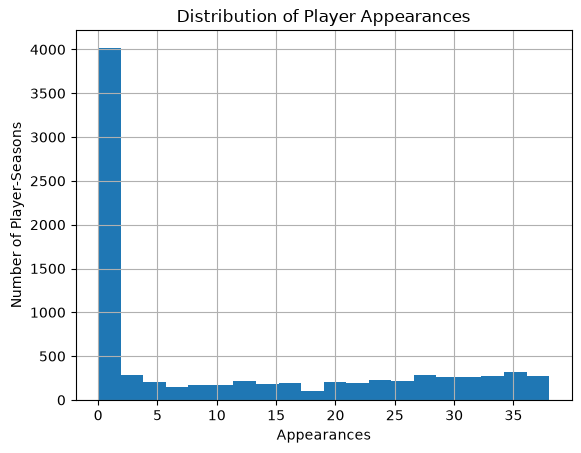

In [139]:
ax = df["Appearances"].hist(bins=20)

ax.set_title("Distribution of Player Appearances")
ax.set_xlabel("Appearances")
ax.set_ylabel("Number of Player-Seasons")

In [140]:
df["Appearances"].value_counts().sort_index()

Appearances
0     3729
1      288
2      157
3      125
4      109
5       96
6       75
7       77
8       89
9       84
10      80
11      93
12     106
13     107
14      87
15      96
16     103
17      89
18      98
19     105
20     102
21     103
22      94
23      96
24     127
25     110
26     102
27     135
28     146
29     128
30     130
31     140
32     118
33     148
34     127
35     160
36     162
37     125
38     150
Name: count, dtype: int64

In [141]:
df["Appearances"] > 38

0       False
1       False
2       False
3       False
4       False
        ...  
8191    False
8192    False
8193    False
8194    False
8195    False
Name: Appearances, Length: 8196, dtype: bool

In [152]:
df[df["Appearances"] > 38][
    ["Name", "Position", "Appearances", "Goals", "Season"]
]

,Name,Position,Appearances,Goals,Season


In [143]:
((df["Appearances"] == 0) & (df["Goals"] > 0)).sum()

np.int64(0)

### Appearance Distribution Observations

The distribution of player appearances shows that a large proportion of player-season records contain very few appearances. This helps explain the difference observed between the mean and median number of appearances for non-high scorers.

During the initial exploratory analysis, four records were identified with more than 38 appearances in a single season. As Premier League clubs play a maximum of 38 league matches per season, these records were inconsistent with the expected season-level data.

Inspection of these records also identified potentially inconsistent goal totals, suggesting that the issue affected the complete player records rather than the `Appearances` feature alone.

No records were found where a player had zero appearances but had scored one or more goals.

The four invalid records were subsequently removed in the data cleaning notebook, and the cleaned dataset was regenerated before continuing the exploratory analysis.